**ASSIGNMENT 8 - Effect of PCA on Regression and Classification Models**

NAME : MADUSSREE RAVI

CSE B

DATE : 09-03-2026

3122235001074

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_validate, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVC

In [3]:
df = pd.read_csv('Dataset.csv')

print(f"Samples: {df.shape[0]}, Features: {df.shape[1]}")

Samples: 1000, Features: 13


In [5]:
df.head()

,Math,Physics,Chemistry,Biology,Total_Science,Average_Science,English,Computer_Science,Sports_Score,Attendance_Percentage,Random_Noise_Feature,Final_Score_Regression,Performance_Level_Classification
0,81.963919,71.591250,65.428104,69.786180,288.769453,71.344844,63.564348,80.470009,59.504621,88.827011,-33.924737,63.165168,Medium
1,73.240525,67.894764,64.315432,68.430136,273.880857,67.563386,62.984703,57.450119,52.445246,90.367064,-15.274973,65.503878,Medium
2,76.775037,72.514786,74.408858,76.584987,300.283667,71.479630,65.997338,81.184728,57.414376,87.493450,-29.869053,75.776067,High
3,81.995615,83.690491,94.668737,88.066081,348.420923,86.445050,75.277242,81.548170,70.720976,75.287512,5.520902,83.577602,High
4,71.149583,58.190393,70.441232,59.457316,259.238524,66.275289,65.647724,74.078977,79.167850,84.222888,59.858927,69.100684,Medium


<Axes: xlabel='Performance_Level_Classification', ylabel='count'>

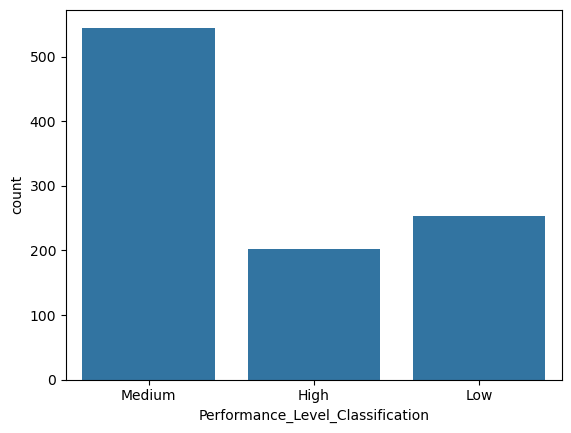

In [6]:
sns.countplot(x=df['Performance_Level_Classification'])

In [7]:
target_reg = 'Final_Score_Regression'
target_clf = 'Performance_Level_Classification'

# 2. PREPROCESSING
X = df.drop([target_reg, target_clf], axis=1)
y_reg = df[target_reg]
y_clf = LabelEncoder().fit_transform(df[target_clf])

# Standardize features (Very Important before PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Components Chosen: 7
Total Explained Variance: 95.90%


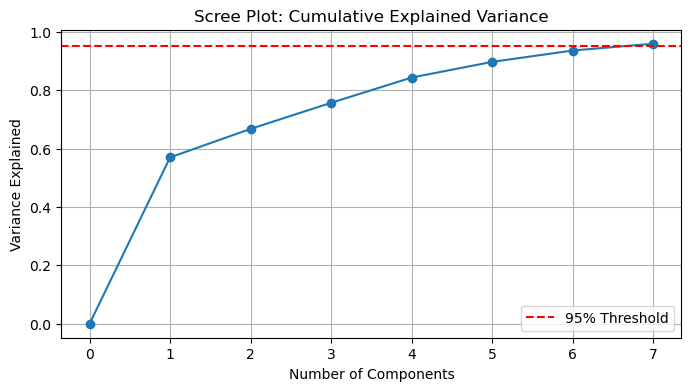

In [8]:
# 3. PCA IMPLEMENTATION
# Retain 95% explained variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# Table 1: PCA Summary Data
explained_var = np.sum(pca.explained_variance_ratio_) * 100
print(f"Components Chosen: {pca.n_components_}")
print(f"Total Explained Variance: {explained_var:.2f}%")

# Scree Plot
plt.figure(figsize=(8, 4))
plt.plot(np.insert(np.cumsum(pca.explained_variance_ratio_), 0, 0), marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.title('Scree Plot: Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Variance Explained')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# 4. CROSS-VALIDATION EVALUATION
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def run_experiment(model, features, target, is_regression=True):
    if is_regression:
        scoring = {'mse': 'neg_mean_squared_error', 'r2': 'r2'}
        cv_results = cross_validate(model, features, target, cv=kf, scoring=scoring)
        return np.mean(np.abs(cv_results['test_mse'])), np.mean(cv_results['test_r2'])
    else:
        scoring = {'acc': 'accuracy', 'f1': 'f1_weighted'}
        cv_results = cross_validate(model, features, target, cv=kf, scoring=scoring)
        return np.mean(cv_results['test_acc']), np.mean(cv_results['test_f1'])

In [10]:
# --- Running Models ---

# Regression
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

lr_no_pca_mse, lr_no_pca_r2 = run_experiment(lr, X_scaled, y_reg)
lr_pca_mse, lr_pca_r2 = run_experiment(lr, X_pca, y_reg)

rf_no_pca_mse, rf_no_pca_r2 = run_experiment(rf, X_scaled, y_reg)
rf_pca_mse, rf_pca_r2 = run_experiment(rf, X_pca, y_reg)

# Classification
log_reg = LogisticRegression(max_iter=1000)
svm = SVC(kernel='rbf')

log_no_pca_acc, log_no_pca_f1 = run_experiment(log_reg, X_scaled, y_clf, False)
log_pca_acc, log_pca_f1 = run_experiment(log_reg, X_pca, y_clf, False)

svm_no_pca_acc, svm_no_pca_f1 = run_experiment(svm, X_scaled, y_clf, False)
svm_pca_acc, svm_pca_f1 = run_experiment(svm, X_pca, y_clf, False)

In [11]:
# 5. FINAL RESULTS TABLES
print("\n--- TABLE 2: REGRESSION RESULTS ---")
results_reg = pd.DataFrame({
    'Metric': ['MSE', 'R2', 'MSE', 'R2'],
    'Model': ['Linear Regression', 'Linear Regression', 'Random Forest', 'Random Forest'],
    'Avg (NoPCA)': [lr_no_pca_mse, lr_no_pca_r2, rf_no_pca_mse, rf_no_pca_r2],
    'Avg (WithPCA)': [lr_pca_mse, lr_pca_r2, rf_pca_mse, rf_pca_r2]
})
print(results_reg)

print("\n--- TABLE 3: CLASSIFICATION RESULTS ---")
results_clf = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-score', 'Accuracy', 'F1-score'],
    'Model': ['Logistic Regression', 'Logistic Regression', 'SVM', 'SVM'],
    'Avg (NoPCA)': [log_no_pca_acc, log_no_pca_f1, svm_no_pca_acc, svm_no_pca_f1],
    'Avg (WithPCA)': [log_pca_acc, log_pca_f1, svm_pca_acc, svm_pca_f1]
})
print(results_clf)


--- TABLE 2: REGRESSION RESULTS ---
  Metric              Model  Avg (NoPCA)  Avg (WithPCA)
0    MSE  Linear Regression    26.233840      26.225062
1     R2  Linear Regression     0.747895       0.748071
2    MSE      Random Forest    28.824234      27.744774
3     R2      Random Forest     0.723201       0.733832

--- TABLE 3: CLASSIFICATION RESULTS ---
     Metric                Model  Avg (NoPCA)  Avg (WithPCA)
0  Accuracy  Logistic Regression     0.734000       0.742000
1  F1-score  Logistic Regression     0.731506       0.740304
2  Accuracy                  SVM     0.743000       0.730000
3  F1-score                  SVM     0.736674       0.722110
